In [ ]:
# # Clone the repository containing the project code
import sys
import os
repo_dir = 'cell-fuzzy-seg'
# if not os.path.exists(repo_dir):
#     !git clone --branch homolog https://github.com/Pedro-io/cell-fuzzy-seg.git
%cd {repo_dir}
sys.path.append(f"/content/{repo_dir}")

Cloning into 'cell-fuzzy-seg'...
remote: Enumerating objects: 464, done.
remote: Counting objects: 100% (263/263), done.
remote: Compressing objects: 100% (178/178), done.
remote: Total 464 (delta 108), reused 214 (delta 62), pack-reused 201 (from 2)
Receiving objects: 100% (464/464), 230.09 MiB | 31.52 MiB/s, done.
Resolving deltas: 100% (179/179), done.
Updating files: 100% (203/203), done.
/content/cell-fuzzy-seg


In [2]:
!pip install -r requirements.txt

INFO: pip is looking at multiple versions of imagecodecs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 90.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 19.8 MB/s eta 0:00:00:00:0100:01


In [3]:
from src.data.load.monuseg_dataset import MonusegDataset

data = MonusegDataset(
  dataset_name="monuseg",
  config_key="monuseg_training"
  )

2026-07-13 22:31:53.826 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:96 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations


In [5]:
data[0]

2026-07-13 22:33:46.405 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-07-13 22:33:46.449 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml


{'id': 'TCGA-18-5592-01Z-00-DX1',
 'image': array([[[181,  88, 132],
         [180,  87, 131],
         [179,  86, 130],
         ...,
         [155,  74, 114],
         [155,  74, 114],
         [157,  75, 123]],
 
        [[185,  90, 132],
         [185,  90, 132],
         [185,  90, 132],
         ...,
         [157,  78, 118],
         [157,  78, 118],
         [158,  78, 123]],
 
        [[187,  92, 132],
         [187,  92, 132],
         [188,  93, 133],
         ...,
         [155,  83, 123],
         [156,  84, 124],
         [160,  80, 123]],
 
        ...,
 
        [[186,  97, 135],
         [185,  96, 134],
         [188,  99, 137],
         ...,
         [144,  68, 115],
         [143,  67, 114],
         [138,  72, 120]],
 
        [[179,  93, 132],
         [177,  91, 130],
         [184,  98, 137],
         ...,
         [146,  68, 116],
         [147,  69, 117],
         [143,  72, 122]],
 
        [[181,  96, 137],
         [181,  95, 134],
         [180,  94, 133],

In [17]:
from cellpose import utils, plot
from skimage import measure

In [18]:
print(len(data))

30


In [25]:
total_diameter = 0
for data_i in data:
  binary_mask = data_i["ground_truth"]
  labeled_mask = measure.label(binary_mask)
  median_diameter, all_diameters = utils.diameters(labeled_mask)
  total_diameter+= median_diameter
  print(f"Diâmetro mediano da imagem {data_i['id']}:{median_diameter}")
  print(f"Diâmetro mínimo da imagem {data_i['id']}:{min(all_diameters)}")
  print(f"Diâmetro máximo da imagem {data_i['id']}:{max(all_diameters)}")
print(f"média do diâmetro mediano total: {total_diameter/30}")

2026-07-13 23:19:14.390 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-07-13 23:19:14.430 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml


2026-07-13 23:19:14.750 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-21-5784-01Z-00-DX1.tif
2026-07-13 23:19:14.791 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-21-5784-01Z-00-DX1.xml


Diâmetro mediano da imagem TCGA-18-5592-01Z-00-DX1:34.3553934334843
Diâmetro mínimo da imagem TCGA-18-5592-01Z-00-DX1:5.477225575051661
Diâmetro máximo da imagem TCGA-18-5592-01Z-00-DX1:128.7400481590713


2026-07-13 23:19:15.022 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-21-5786-01Z-00-DX1.tif
2026-07-13 23:19:15.069 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-21-5786-01Z-00-DX1.xml


Diâmetro mediano da imagem TCGA-21-5784-01Z-00-DX1:20.775663783985824
Diâmetro mínimo da imagem TCGA-21-5784-01Z-00-DX1:5.656854249492381
Diâmetro máximo da imagem TCGA-21-5784-01Z-00-DX1:44.474711915874174


...

Diâmetro mediano da imagem TCGA-HE-7130-01Z-00-DX1:17.58969042850512
Diâmetro mínimo da imagem TCGA-HE-7130-01Z-00-DX1:4.898979485566356
Diâmetro máximo da imagem TCGA-HE-7130-01Z-00-DX1:59.06775770248944


2026-07-13 23:19:25.880 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-NH-A8F7-01A-01-TS1.tif
2026-07-13 23:19:25.922 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-NH-A8F7-01A-01-TS1.xml


Diâmetro mediano da imagem TCGA-KB-A93J-01A-01-TS1:21.498510523728477
Diâmetro mínimo da imagem TCGA-KB-A93J-01A-01-TS1:6.244997998398398
Diâmetro máximo da imagem TCGA-KB-A93J-01A-01-TS1:54.52522352086234


2026-07-13 23:19:26.131 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-RD-A8N9-01A-01-TS1.tif
2026-07-13 23:19:26.179 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-RD-A8N9-01A-01-TS1.xml


Diâmetro mediano da imagem TCGA-NH-A8F7-01A-01-TS1:32.83946577066463
Diâmetro mínimo da imagem TCGA-NH-A8F7-01A-01-TS1:7.416198487095663
Diâmetro máximo da imagem TCGA-NH-A8F7-01A-01-TS1:108.07404868885037
Diâmetro mediano da imagem TCGA-RD-A8N9-01A-01-TS1:21.43920417481474
Diâmetro mínimo da imagem TCGA-RD-A8N9-01A-01-TS1:6.855654600401044
Diâmetro máximo da imagem TCGA-RD-A8N9-01A-01-TS1:45.95650117230423
média do diâmetro mediano total: 25.83661872535004


2026-07-13 22:54:20.848 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-21-5786-01Z-00-DX1.tif
2026-07-13 22:54:20.924 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-21-5786-01Z-00-DX1.xml


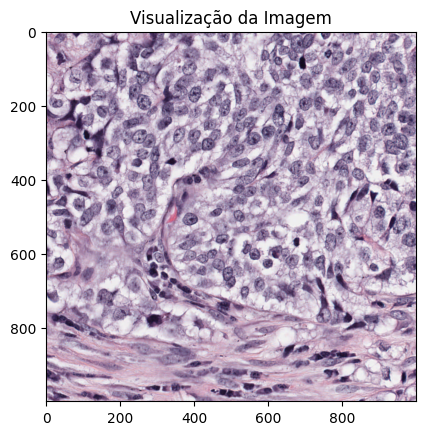

In [ ]:
from cellpose import plot, io
import matplotlib.pyplot as plt

img = data[2]["image"]
plt.imshow(img)
plt.show()